# Sota solvers and pruning techniques

In [3]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

%matplotlib inline

%load_ext autoreload
%autoreload 2

## Importing and using the new graph

We use a 5x5 grid network, 25 nodes in total

In [4]:
sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

In [5]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

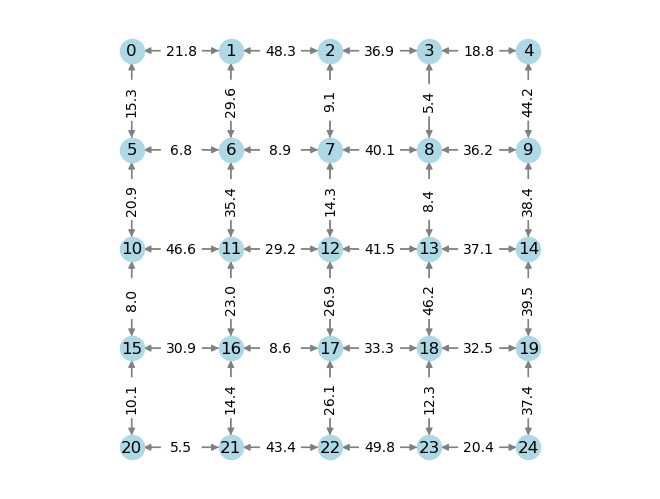

In [5]:
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

## Algorithms usage

In [7]:
destination_node = 20
time_budget = 300

### StandardSOTA

In [12]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

In [13]:
sota = StandardSOTASolver(graph, destination_node, time_budget)
sota.solve();

Convergence reached!
End of iterations


In [14]:
sota.print_sota_matrix()
sota.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  5  5  5]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  7  7]
 ...
 [-1 -1 -1 ... 17 17 17]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [15]:
sota.extract_path(3)

[3, 2, 7, 12, 17, 16, 15, 20]

### SingleIteration SOTA

In [24]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
sota2 = SingleIterationSOTASolver(graph, destination_node, time_budget)

In [25]:
sota2.solve()
sota2.print_sota_matrix()
sota2.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  1  5  1]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  1  1]
 ...
 [-1 -1 -1 ... 21 21 21]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [26]:
sota2.extract_path(3)

[3, 2, 1, 6, 11, 10, 15, 20]

### Precomputing techniques: Reach

#### Brute-force Reach

In [9]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
r = bfReach(graph, s)

In [10]:
r.reach_computation()

Computing reach values...
Reach values computed


array([12.37980199, 26.83374876, 46.02069332, 22.98661169, 13.86546712,
       22.37756144, 38.92577814, 30.63261947, 22.98661169, 27.9620986 ,
       41.52696536, 46.35191484, 41.98914855, 28.87747902, 30.77064295,
       36.23485462, 29.35568179, 40.79085084, 27.42530996, 37.35451841,
       19.92644511, 12.58028783, 15.09970989, 30.88100423,  0.        ])

In [11]:
r.reach_pruning()

Pruning nodes...
Pruned nodes: {24, 1}


{1, 24}

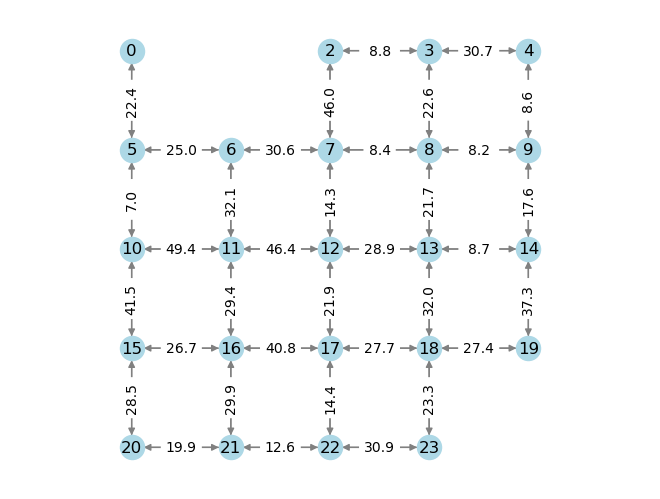

In [12]:
graph.print_graph()

#### Deterministic Reach

In [16]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, destination_node)

In [17]:
r.reach_computation()

Computing reach values...
Reach values computed


array([ 6.73367004, 31.98854853, 31.98854853, 14.50807646,  6.78618332,
       16.09098533, 44.96274222, 22.61991775, 41.37786347, 32.78011589,
        8.00350687, 26.84331131, 32.59374031, 14.50115939, 22.4775472 ,
       22.81311843, 21.35970826, 32.59374031, 19.4677743 , 21.65711624,
        0.        , 15.29164821, 25.04698949, 43.05831705,  0.        ])

In [18]:
r.reach_pruning()

Pruning nodes...
Pruned nodes: {1, 3, 4, 11, 13, 16, 19, 22, 24}


{1, 3, 4, 11, 13, 16, 19, 22, 24}

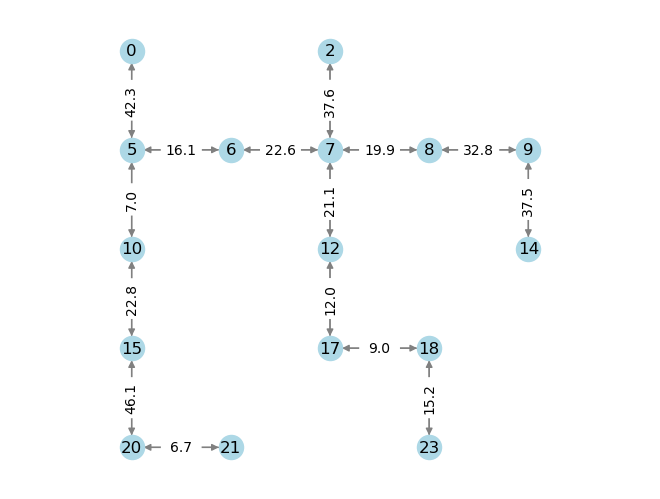

In [19]:
graph.print_graph()

### Precomputing techniques: Arc-flags

#### Brute-force Arc-flags

In [28]:
adj_matrix, var_matrix = matrix.compute_matrices()

In [29]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
f = bfArcFlags(graph, 4, s)

In [30]:
f.arcflags_computation()


Executing partition...
Partitioning of the graph in 4 regions executed in 0.0184 seconds!
Computing arcflags...
Arcflags computed!


{(np.int64(0), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(0), np.int64(5)): {0: True, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(1), np.int64(2)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(3)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(3), np.int64(2)): {0: True, 1: True, 2: True, 3: False},
 (np.int64(3), np.int64(4)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(3), np.int64(8)): {0: True, 1: False, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: True, 1: True, 2: True, 3: False},
 (np.int64(4), np.int64(9)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(5), np.int64(0)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(5), np.int64(6)): {0: True, 1:

In [31]:
f.arcflags_pruning()

Pruning edges...
[ArcFlags] Pruned 44 edges for destination 20 (region 1).


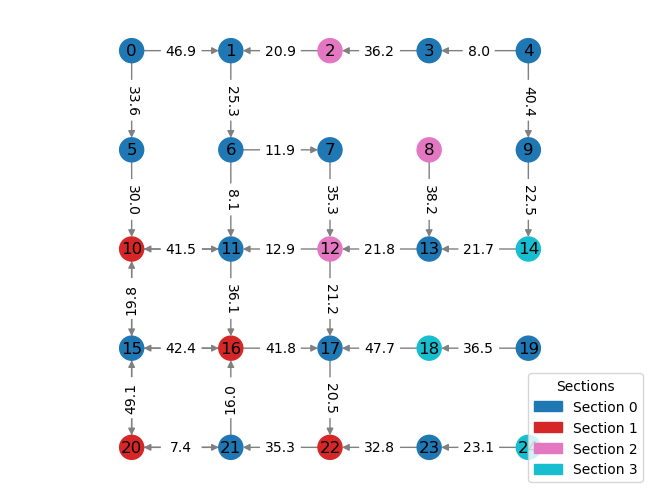

In [32]:
f.print_graph_sections()

#### Deterministic Arc-flags

In [33]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, 4, d, destination_node)

In [34]:
f.arcflags_computation()

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0188 seconds!
Computing arcflags...
Arcflags computed!


{(np.int64(0), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(0), np.int64(5)): {0: True, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(1), np.int64(2)): {0: False, 1: False, 2: True, 3: False},
 (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(3)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: True, 1: False, 2: True, 3: True},
 (np.int64(3), np.int64(2)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(3), np.int64(4)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(9)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(5), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(5), np.int64(6)): {0: True, 1:

In [35]:
f.arcflags_pruning()

Pruning edges...
[ArcFlags] Pruned 36 edges for destination 20 (region 1).


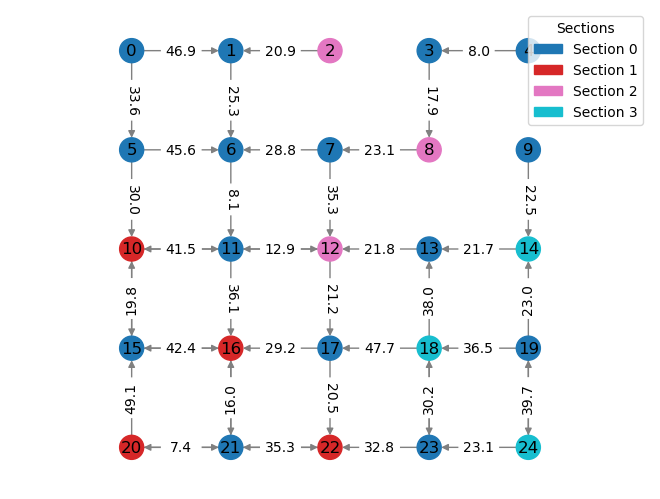

In [36]:
f.print_graph_sections()

## Query times comparisons

Time-comparisons between one simple use case on a 5x5 graph.

In [55]:
matrix = Matrix(10, 10)
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

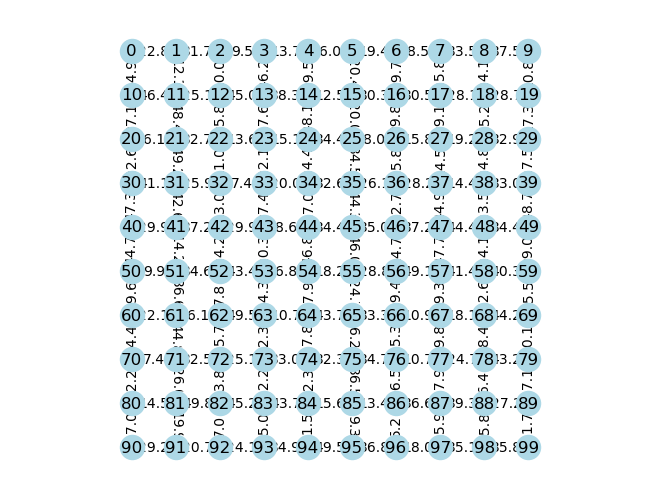

In [40]:
graph.print_graph()

In [60]:
# standard sota solver

import time

destination_node = 72
time_budget = 400

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

s = StandardSOTASolver(graph, destination_node, time_budget)

start = time.time()
s.solve()
end = time.time()

print(f"Policy computed on {end-start:.4f} seconds")

print(s.get_policy_matrix()[:, -1])


Policy computed on 986.5715 seconds
[10 11 12 13 14 15  5  6  7  8 11 21 22 23 24 14 26 27 17 18 21 31 32 33
 34 24 36 37 27 28 31 41 42 32 44 34 46 47 48 38 50 51 52 53 54 55 56 57
 47 48 51 61 62 52 64 65 66 56 68 58 61 71 72 73 63 64 65 66 67 68 71 72
 -1 72 73 74 75 76 77 78 70 71 72 73 83 84 85 86 87 88 91 81 82 92 84 94
 95 87 97 98]


In [61]:
# single iteration sota solver

import time

#destination_node = 23
#time_budget = 300

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

s = SingleIterationSOTASolver(graph, destination_node, time_budget)

start = time.time()
s.solve()
end = time.time()

print(f"Policy computed on {end-start:.4f} seconds")

print(s.get_policy_matrix()[:, -1])

Policy computed on 196.7678 seconds
[10 11 12 13 14 15  5  6  7  8 20 21 22 23 24 14 26 27 17 29 21 31 32 33
 34 24 36 37 27 28 31 41 42 43 44 34 46 47 48 38 50 51 52 53 43 55 56 57
 47 48 51 61 62 52 64 65 66 56 68 58 61 71 72 73 63 64 65 66 67 68 71 72
 -1 72 73 74 75 76 77 78 70 71 72 73 83 84 85 86 87 88 91 81 82 92 84 94
 95 96 97 98]


In [62]:
# reach

import time

#destination_node = 23

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, destination_node)

start_reach = time.time()
r.reach_computation()
r.reach_pruning()
end_reach = time.time()

s = StandardSOTASolver(graph, destination_node, time_budget)
start_standard = time.time()
s.solve()
end_standard = time.time()
print(s.get_policy_matrix()[:, -1])

s = SingleIterationSOTASolver(graph, destination_node, time_budget)
start_iterative = time.time()
s.solve()
end_iterative = time.time()
print(s.get_policy_matrix()[:, -1])

reach_time = end_reach-start_reach

print(f"Reach computed and pruned in {reach_time:.4f} seconds")
print(f"Standard SOTA policy computed in {end_standard-start_standard:.4f} seconds")
print(f"Standard-pruned query time: {end_standard-start_standard+reach_time:.4f} seconds")
print(f"Single iteration policy computed in {end_iterative-start_iterative:.4f} seconds")
print(f"SingleIteration-pruned query time: {end_iterative-start_iterative+reach_time:.4f} seconds")

Computing reach values...
Reach values computed
Pruning nodes...
Pruned 45 nodes: {0, 2, 3, 8, 11, 13, 15, 17, 19, 20, 21, 22, 23, 27, 34, 36, 38, 40, 41, 42, 43, 44, 46, 47, 51, 53, 54, 61, 63, 65, 69, 70, 71, 73, 74, 76, 81, 82, 88, 90, 91, 93, 95, 97, 99}
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 62 -1 -1 -1 -1 -1 -1 -1 -1 -1 72 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 62 -1 -1 -1 -1 -1 -1 -1 -1 -1 72 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
Reach computed and pruned in 1.4382 seconds
Standard SOTA policy computed in 77.4339 seconds
Standard-pruned query time: 78.8721 

In [63]:
# arcflags

import time

#destination_node = 23

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, d, destination_node)

start_reach = time.time()
f.arcflags_computation()
f.arcflags_pruning()
end_reach = time.time()

s = StandardSOTASolver(graph, destination_node, time_budget)
start_standard = time.time()
s.solve()
end_standard = time.time()
print(s.get_policy_matrix()[:, -1])

s = SingleIterationSOTASolver(graph, destination_node, time_budget)
start_iterative = time.time()
s.solve()
end_iterative = time.time()
print(s.get_policy_matrix()[:, -1])

reach_time = end_reach-start_reach

print(f"Arcflags computed and pruned in {reach_time:.4f} seconds")
print(f"Standard SOTA policy computed in {end_standard-start_standard:.4f} seconds")
print(f"Standard-pruned query time: {end_standard-start_standard+reach_time:.4f} seconds")
print(f"Single iteration policy computed in {end_iterative-start_iterative:.4f} seconds")
print(f"SingleIteration-pruned query time: {end_iterative-start_iterative+reach_time:.4f} seconds")

Executing partition...
Partitioning of the graph in 5 regions executed in 0.0050 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 71 edges for destination 72 (region 2).


KeyboardInterrupt: 

Computing reach values...
Reach values computed
Pruning nodes...
Pruned 18 nodes: {32, 1, 4, 5, 37, 7, 8, 41, 42, 11, 12, 46, 47, 16, 19, 22, 28, 30}


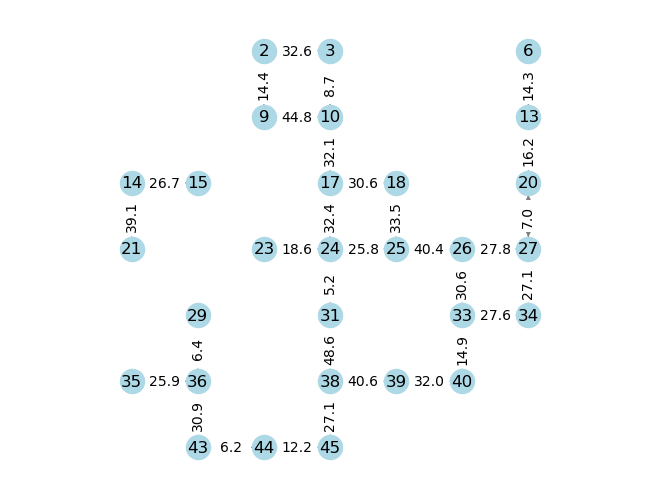

In [51]:
m = Matrix(7, 7, link_var_max=0.5)
m.compute_matrices()

adj_matrix, var_matrix = m.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, 38)
r.reach_computation()
r.reach_pruning()
graph.print_graph()

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0040 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 27 edges for destination 38 (region 1).


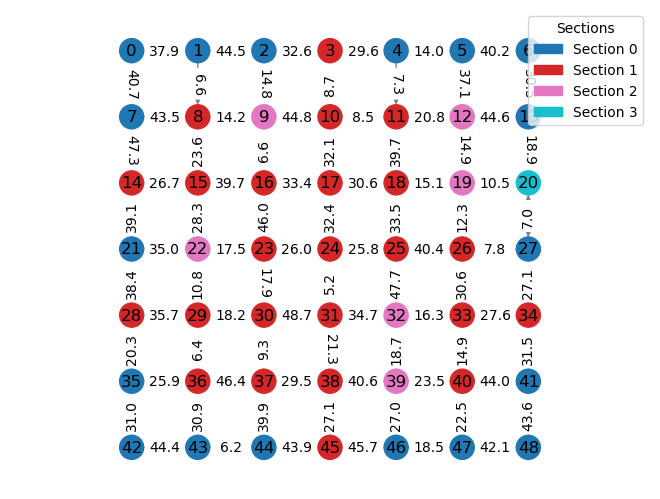

In [53]:
adj_matrix, var_matrix = m.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, d, 38)

f.arcflags_computation()
f.arcflags_pruning()
f.print_graph_sections()

Results (in seconds):

|   |s-SOTA|si-SOTA|s-SOTA +detReach|si-SOTA +detReach|s-SOTA +detArcFlags|si-SOTA +detArcFlags|
|---|---|---|---|---|---|---|
|5x5 graph|25.7516|10.4251|4.2060 ⚠️|1.8326 ⚠️|14.5475|5.5268|

## Optimality of the solutions

Are the det-pruned solutions optimal? We will compare some of them

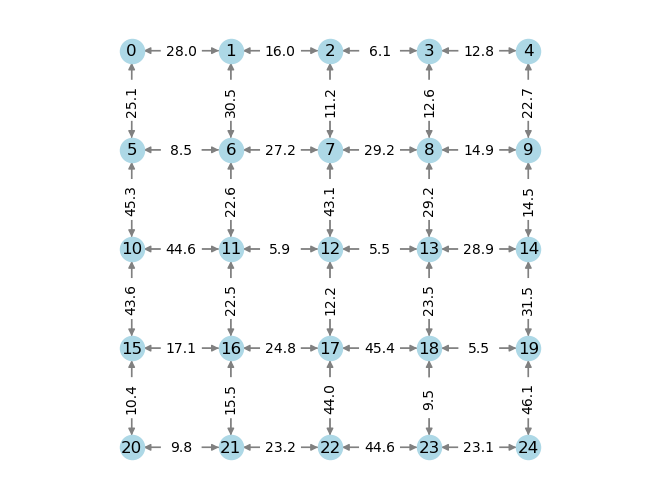

In [3]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

In [9]:
def extract_path_from_policy(policy, start_node):
        """
        Extracts the optimal path for time-index watching the policy row.
        It stops if we get to destination, we get to a node -1.
        @return: list of nodes representing the optimal path from source to destination
        """
        path = [start_node]
        current = start_node

        max_steps = len(policy)*2
        steps = 0

        while True:
            # retrieving the next node
            next_node = policy[current]

            # stop if next = -1 or destination
            if next_node == -1:
                break

            path.append(int(next_node))
            current = next_node

            steps += 1

            if steps > max_steps:
                print("[Warning]A loop in the policy matrix was detected")
                break

        return path

In [45]:
#matrix = Matrix(5, 5, link_var_max=0.5)
#adj_matrix, var_matrix = matrix.compute_matrices()

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, 4, d, 20)
f.arcflags_computation()
f.arcflags_pruning()

s = StandardSOTASolver(graph, 20, 200)
s.solve()
policy = s.get_policy_matrix()[:,-1]

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0259 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 12 edges for destination 20 (region 1).


In [46]:
print(s.get_sota_matrix()[1,-1])
print(s.get_sota_matrix()[2,-1])
print(s.get_sota_matrix()[4,-1])
print(s.get_sota_matrix()[19,-1])

6.695003600262306e-06
1.7108241687354248e-07
5.518462600813787e-08
3.1377707756134825e-06


In [43]:
policy

array([ 5,  6,  7,  2,  3, 10,  5,  6, 13,  8, 15, 16, 11, 12, 13, 20, 21,
       22, 17, 24, -1, 20, 21, 22, 23])

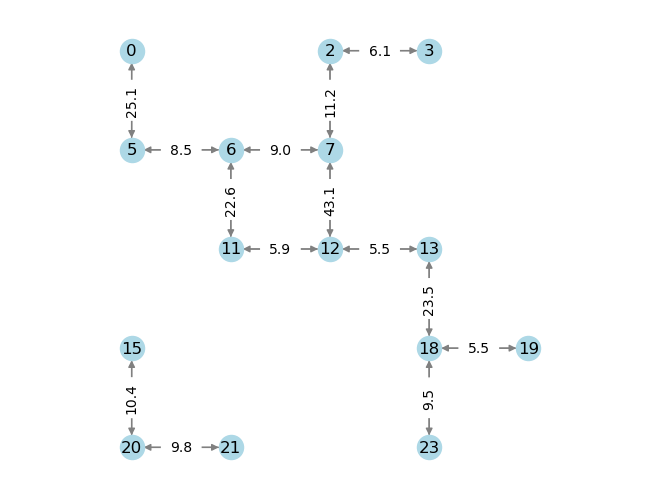

In [32]:
# printing the optimal path for [1,2,4,19]

path = extract_path_from_policy(policy, 19)
graph.print_graph(path, grid_shape=(5,5))